In [1]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt
from ddeint import ddeint
import seaborn as sns
from sympy.printing.pretty.pretty_symbology import line_width



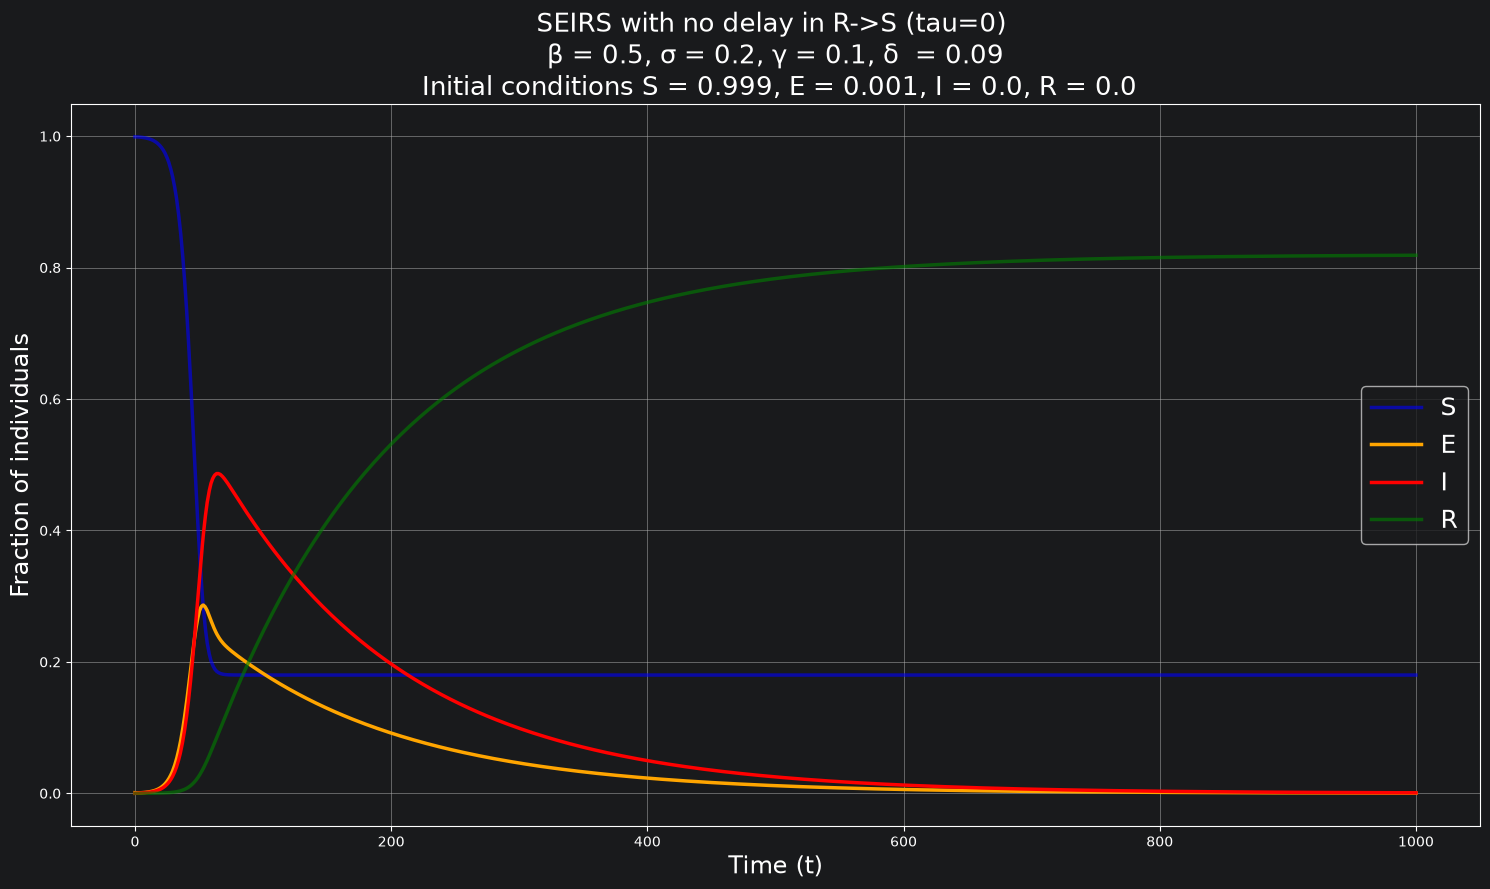

In [2]:
N     = 1.0   # total population
beta  = 0.5      # infection rate
sigma = 0.2       # E -> I rate
gamma = 0.1       # I -> R rate
delta = 0.09
tau   = 0      # delay: time in R before returning to S
I0    = 0.001       # initial infectious
T     = 1000.0    # total time to simulate

#defining the model
def model(Y, t):
    #defining the values S, E, I, and R
    S, E, I, R = Y(t)
    R_delayed = Y(t - tau)[2]
    #defining all of our equations, with the R_delayed (a time lag introduced in R->S)
    dS = -beta * S * I / N + delta * R_delayed
    dE = beta * S * I / N - sigma * E
    dI = sigma * E - gamma * I
    dR = gamma * I - delta * R_delayed
    return np.array([dS, dE, dI, dR])


def history(t):
    return np.array([N - I0, I0, 0.0, 0.0])


tt = np.linspace(0, T, 3000)
S, E, I, R = ddeint(model, history, tt).T

plt.figure(figsize=(15, 9))
plt.plot(tt, S, label="S", color = 'blue', alpha = 0.6, lw = 2.5)
plt.plot(tt, E, label="E", color = 'orange', alpha = 1, lw = 2.5)
plt.plot(tt, I, label="I", color = 'red', lw = 2.5)
plt.plot(tt, R, label="R", color = 'green', alpha = 0.6, lw = 2.5)
plt.xlabel("Time (t)", fontsize = 17)
plt.ylabel("Fraction of individuals", fontsize = 17)
plt.title(f"SEIRS with no delay in R->S (tau={tau}) \n β = {beta}, σ = {sigma}, γ = {gamma}, δ  = {delta} \n Initial conditions S = 0.999, E = 0.001, I = 0.0, R = 0.0", fontsize = 19)
plt.legend(fontsize = 18)
plt.grid(alpha=0.7)
plt.tight_layout()
plt.savefig("seirs.png", dpi=130)



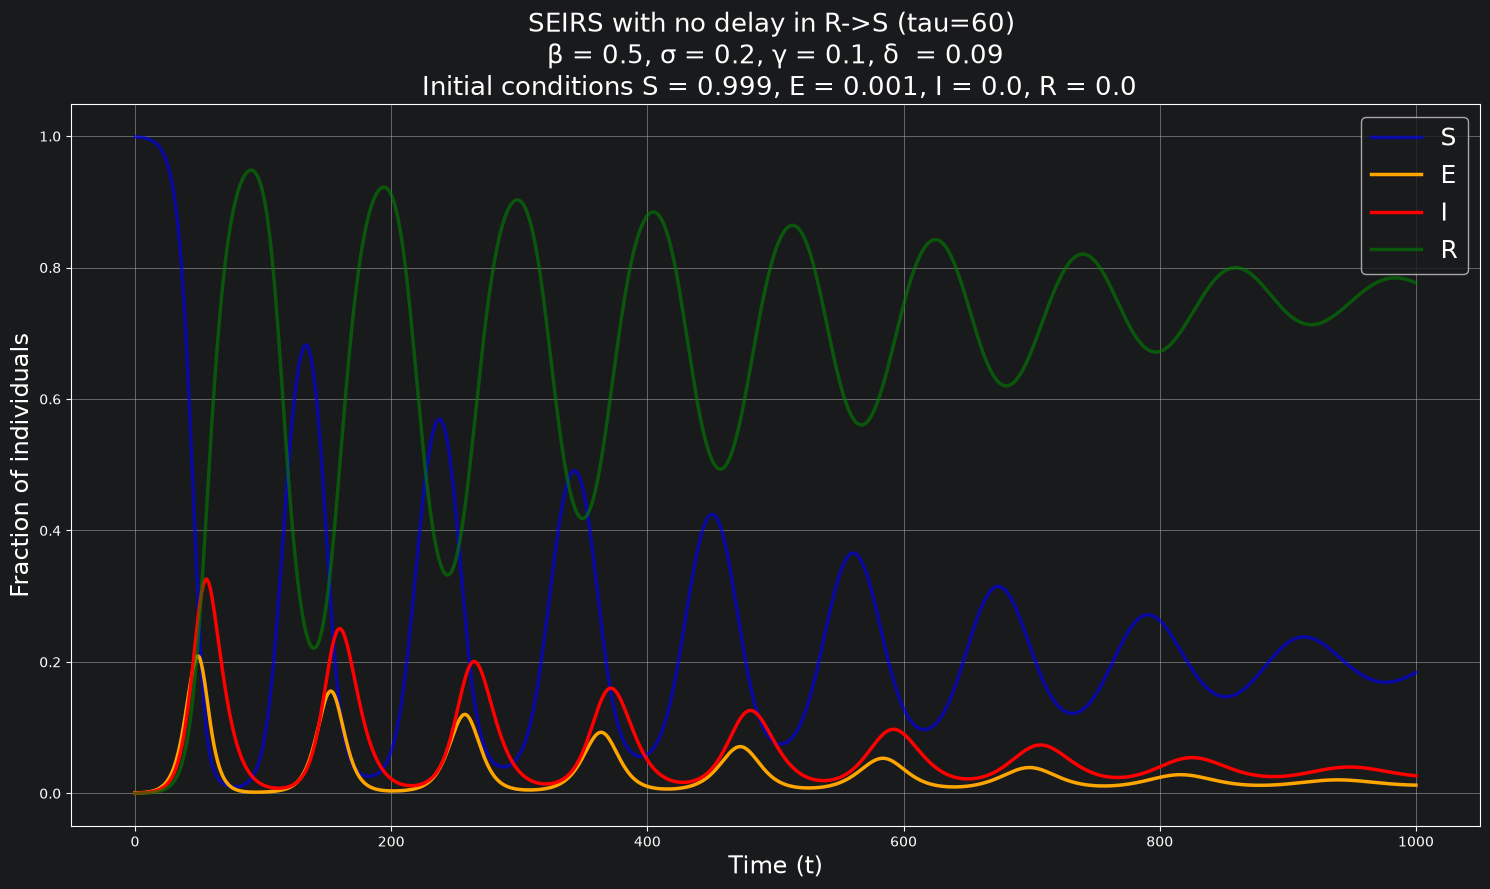

In [3]:

N     = 1.0   # total population
beta  = 0.5      # infection rate
sigma = 0.2       # E -> I rate
gamma = 0.1       # I -> R rate
delta = 0.09
tau   = 60     # delay: time in R before returning to S
I0    = 0.001       # initial infectious
T     = 1000.0    # total time to simulate

tt = np.linspace(0, T, 3000)
S, E, I, R = ddeint(model, history, tt).T

plt.figure(figsize=(15, 9))
plt.plot(tt, S, label="S", color = 'blue', alpha = 0.6, lw = 2.5)
plt.plot(tt, E, label="E", color = 'orange', alpha = 1, lw = 2.5)
plt.plot(tt, I, label="I", color = 'red', lw = 2.5)
plt.plot(tt, R, label="R", color = 'green', alpha = 0.6, lw = 2.5)
plt.xlabel("Time (t)", fontsize = 17)
plt.ylabel("Fraction of individuals", fontsize = 17)
plt.title(f"SEIRS with no delay in R->S (tau={tau}) \n β = {beta}, σ = {sigma}, γ = {gamma}, δ  = {delta} \n Initial conditions S = 0.999, E = 0.001, I = 0.0, R = 0.0", fontsize = 19)
plt.legend(fontsize = 18)
plt.grid(alpha=0.7)
plt.tight_layout()
plt.savefig("seirs.png", dpi=130)
